# Merge Track Frame and Mission Plan 
---

This notebook will read all the data from a kmz for a cycle and save the results a gpkg.  It also take this plan an intersect it with the track frame data base so the frame show the actual extent of the data aquisition, including short frames and 80MHz half-width frames.

In [1]:
import geopandas as gpd
import pandas as pd
import fiona
from matplotlib import pyplot as plt
import shapely
from shapely.geometry import Polygon, MultiPolygon
import numpy as np
fiona.drvsupport.supported_drivers['LIBKML'] = 'rw'
from datetime import datetime
import pytz
from subprocess import call
import os
import warnings
from pyproj import CRS
from shapely.geometry import Polygon, mapping, shape, box, Point

## Get Modes

This cell produces a dictionary, `modeToMnemonic`, to map the mode numbers to mode mnemonics. It also produces a dictionary with the list of nodes for each bandwidth, `bwModes`. 

In [2]:
bwModes = {'5': [], '20': [], '40': [], '80': []}
modeToMnemonic = {}
with open('modes', 'r') as fp:
    for line in fp:
        line.replace('"', '')
        pieces = line.split()
        modeNumber = pieces[0]
        modeName = ''.join(pieces[1:])
        bw = modeName[3:6].split('W')[0]
        bwModes[bw].append(modeNumber)
        modeToMnemonic[modeNumber] = modeName

## Support Functions

The function `computeTrack` maps the time in the mission plan to a track number for ROP358 (could changed with other ROPs?). 

In [3]:
def computeTrack(myTime):
    '''
    Use time to compute track. Needs fine tuning near equator.
    '''
    secsCycle = 12. * 86400.
    track = ((myTime.timestamp() + 3100 + 25160 ) % secsCycle)/secsCycle * 173
    track = (track - 141) % 173
    return int(track)

def getMode(obsFile, layer, mode, direction, tMin=0, tMax=3600, bbox=(-180, 58, 180,90)):
    '''
    Pull the rows for a layer (in kml file), mode (mode number), direction (ascending/descending).
    Optionally select only those data takes with a duration defined by tMin and tMax. 
    Filter geographically with bbox. 
    '''
    # Layer names contain direction
    if direction in layer and mode in layer:
        # read kml for specfied layer
        gdf = gpd.read_file(obsFile, bbox=bbox, drivers='LIBKML', layer=layer)
        # Only proceed if ther is data
        if gdf.shape[0] <= 0:
            return None
        # Compute data take duration and filter by duration
        gdf['deltaT'] = (gdf['end'] - gdf['begin']).apply(pd.Timedelta.total_seconds)
        tkeep = (gdf['deltaT'] > tMin) & (gdf['deltaT'] <= tMax)
        gdf = gdf[tkeep]
        # Compute the track number
        gdf['track'] = gdf['begin'].apply(computeTrack)
        gdf['mode'] = mode
        # reset indices to reflect order in frame
        gdf.reset_index(drop=True, inplace=True)
        #print(f'M{mode} {gdf.shape[0]}', end=' ')
        if gdf.shape[0] > 0: 
            return gdf 
    return None

Read the datatakes from the kmls and save to a geopandas dataFrame.

In [4]:
def getDataTakes(obsFile, direction, bw, bwModes, bbox=(-180, -90, 180,-60), saveToFile=False, tMin=0, tMax=3600, fileNameBase='Antarctica'): 
    '''
    Get all the data takes for a cycle (cycle number) with a given direction (ascending/descending).
    if saveToFile, then save to file with fileNameBase_bwMHz.Direction.cycleN.tMin.tMax.gpkg.
    '''
    # All L-band data modes for given BWs
    modes = bwModes[str(bw)]
    gdfs = []
    with open(obsFile, 'rb') as fp:
        for layer in fiona.listlayers(fp):
            for mode in modes:
                gdf = getMode(obsFile, layer, mode, direction, tMin=tMin, tMax=tMax, bbox=bbox)
                if gdf is not None:
                    gdf.drop('timestamp', inplace=True, axis=1)
                    gdf['bandwidth'] = bw
                    gdfs.append(gdf)
    allData = gpd.GeoDataFrame(pd.concat(gdfs))
    # Get rid of invalid timestamps so the results can be saved
    # Reset index to reflect current row order
    allData.reset_index(drop=True, inplace=True)
    # save if requested
    if saveToFile:
        shortDirection = {'ascending': 'Asc', 'descending': 'Desc'}[direction]
        allData.to_file(f'Antarctica/{fileNameBase}_{bw}MHz.{shortDirection}.{cycle:03d}.{tMin}.{tMax}.gpkg')
    return allData

Undo multipolygons, which work well for display, but can screw up the intersections. 

In [5]:
def mergePoly(myGeometry):
    ''' 
    Merge multipilygons. These appear to occur where a frame straddles the -180, 180 transition. 
    Update the <-180 values with +360, to produce continue > 180 values. Then merge the polygons.
    '''
    # Single polygon in the Multipolygon, the return it
    if len(myGeometry.geoms) == 1:
        return list(myGeometry.geoms)[0]
    # Loop through multipolygons and fix coordinates.
    polygons = []
    for poly in myGeometry.geoms:
        x, y = np.array(poly.exterior.xy)
        x[x < 0.] = x[x < 0.] + 360
        newPoly = Polygon(zip(x,y))
        polygons.append(newPoly)
    # merge the result
    merged = shapely.ops.unary_union(MultiPolygon(polygons))
    # If not merged discard, which shouldn't happen
    if merged.geom_type == 'MultiPolygon':
        return None
    return merged

This function does the intersection of the swath with the frame to determine the actual area aquired for the frame. If swath doesn't full cover the frame the outline for the partial frame will be returned. The percent coverage will be computed, but because the width of swath is less than that of the frame, it needs to be renormalized so a full skinny frame (intersected with swath) will register a coverage value of 1. Note, the coverage value could have errors of a few percent (not verified).

In [6]:
def intersectFrameAndSwath(swath, frame):
    ''' 
    Take a swath row from the acquisition plan and a frame row from the track frame data base
    and find the intersection. Return an updated frames with the geometry for just the area acquired
    '''
    # intersections are not perfect and lead to biases in the estimated area, these values force full frame coverage to 1
    # These are initial guesses, they get renormalized below.
    biases = {80: 0.48256000000000004,
              40: 0.961515,
              5: 0.9600569999999999,
             20: 0.9600569999999999}# There are no 20s and this is just a guess
    geom1 = swath['geometry'].buffer(0)
    oldGeometry = frame['geometry'].buffer(0)
    newGeometry = geom1.intersection(oldGeometry)
    # merge the multipolygons
    if newGeometry.geom_type == 'MultiPolygon':
        newGeometry = mergePoly(newGeometry)
        if newGeometry is None:
            return None
    frame['geometry'] = newGeometry
    areaCoverage = newGeometry.area/oldGeometry.area
    areaCoverage /= biases[ swath['bandwidth']]
    frame['coverage'] = areaCoverage
    frame['mode'] = swath['mode']
    frame['bandwidth'] = swath['bandwidth']
    return frame

The intersections are carried out in a cartesian coordinate system, but any projection does not work everywhere. Polarstereo works well at the poles, but is by hemisphere and to distorted near equator. UTM avoids wraps at +/-180, but the same zone flips the northing sign at equator. Mercator works at the equator, but wraps at +/-180 (solve with custom mercator centered at a longitude appropriate for the swath).

In [7]:
def getXYEPSG(geom):
    lon, lat = geom.centroid.x, geom.centroid.y
    lonMin, latMin, lonMax, latMax = geom.bounds
    # NSIDC north 
    if lat > 60:
        epsg = {'epsg': 3413}
    # NSIDC south
    elif lat < -60:
        epsg = {'epsg': 3031}
    # Mercator to avoid UTM issues at equator
    elif lat > -30 and lat < 30:
        # Mercator centered on lonMin to avoid wrap
        #if (lon > 150 and lon < 210) or (lon < -150) :
        epsg = {'crs':
                 f"+proj=tmerc +lat_0=0 +lon_0={lonMin} +k=0.9996 +x_0=500000 +y_0=0 +datum=WGS84 +units=m +no_defs"}
        # mercator for rest of the world
        #else:
        #    epsg = {'epsg': 3395}
    else:    
        # Compute UTM zone number
        zone_number = int((lon + 180) / 6) + 1
        # Determine hemisphere
        hemisphere = 'north' if lat >= 0 else 'south'
        # Construct EPSG code (north uses 32600 + zone, south uses 32700 + zone)
        epsg = {'epsg': 32600 + zone_number if hemisphere == 'north' else 32700 + zone_number}
    if 'epsg' in epsg:
        crs = CRS.from_epsg(epsg['epsg'])
    elif 'crs' in epsg:
        crs = CRS.from_string(epsg['crs'])
    else:
        print('Error', epsg)
    return epsg, crs

Handle wrapped geometries (mostly written by chatGPT).

In [8]:

def flag_wrapped_geometries(gdf, threshold=180):
    """
    Flag geometries that likely wrap around the dateline (-180/180).
    
    Parameters:
        gdf (GeoDataFrame): Input GeoDataFrame in EPSG:4326.
        threshold (float): Longitude span threshold to flag a geometry (default: 180).
        
    Returns:
        Series of booleans indicating wrapped geometries.
    """
    if gdf.crs.to_epsg() != 4326:
        raise ValueError("GeoDataFrame must be in EPSG:4326 (WGS84)")

    bounds = gdf.geometry.bounds
    lon_span = bounds['maxx'] - bounds['minx']
    return lon_span > threshold


def unwrap_geometry(geom):
    '''
    For rectangles with +- 180, add 360 to negative lon
    '''
    lon, lat = geom.exterior.xy
    lat = [x for x in lat]
    lon = [x + 360 if x < 0 else x for x in lon]
    coords = list(zip(lon, lat))
    return shape({'type': 'Polygon', 'coordinates': [coords]})

## Load KMLs

There is an offset between track numbers in the TF dB and the ROP KMLs. This function will convert the database version to the kml version. The offset may change as the ROP evolves.

In [9]:
def trackToSwath(track):
    return (track +97) % 173

Convert kmz to kml.

Read KMLs and convert to geopkgs. Seperate into short (<=8s) and long (>8s) data takes.

In [10]:
cycle = 7
dfs =  {}
# tracks in swath and TF dB offset releative to each others
def readCycleKMLs(cycle, bwModes,  bbox=[-180, -90, 180, 90]):
    obsFile = f'ROP358/observationkmzs/Cycle{cycle:03d}_vis.kml'
    #
    fileNameBase = 'Global'
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # suppress deprecation warndings
        for bw in [5, 20, 40, 80]:
            print(bw, end=' ')
            dfs[f'Asc{bw}All'] = getDataTakes(obsFile, 'ascending', bw, bwModes, bbox=bbox, 
                                              saveToFile=True, tMin=0, tMax=3600, fileNameBase=fileNameBase);
            dfs[f'Desc{bw}All']  = getDataTakes(obsFile, 'descending', bw, bwModes,bbox=bbox, 
                                                saveToFile=True, tMin=0, tMax=3600, fileNameBase=fileNameBase);
            dfs[f'Asc{bw}Long'] = getDataTakes(obsFile, 'ascending', bw, bwModes, bbox=bbox,
                                               saveToFile=True, tMin=8, tMax=3600, fileNameBase=fileNameBase);
            dfs[f'Desc{bw}Long'] = getDataTakes(obsFile, 'descending', bw, bwModes, bbox=bbox,
                                                saveToFile=True, tMin=8, tMax=3600, fileNameBase=fileNameBase);
            dfs[f'Asc{bw}Short'] = getDataTakes(obsFile, 'ascending', bw, bwModes, bbox=bbox,
                                                saveToFile=True, tMin=0, tMax=8, fileNameBase=fileNameBase);
            dfs[f'Desc{bw}Short'] = getDataTakes(obsFile, 'descending', bw, bwModes, bbox=bbox,
                                                 saveToFile=True, tMin=0, tMax=8, fileNameBase=fileNameBase);
    print(f'cycle {cycle} read')
    return dfs

Because tracks wrap around the entire globe, its easly to run into projection problems. This function does a crude prescreen of the frames that likely intersect the swath based on latitude limits. It got a bit complicated due to centroids not computing properly on a few frames where the longitudes wrap. There is also an issue where a pass ascends towards the equator so that once it crosses, the track changes. The flag `checkEquator` is to handle these swaths.

In [11]:
def preScreen(TF, track, swathLL, checkEquator=False):
    ''' 
    Limit frames to reasonable range of lat/lon around swath
    '''
    TFTrackAll = TF[TF['track'] == track]
    lonMin, latMin, lonMax, latMax = swathLL.geometry.iloc[0].bounds
    latC = (latMin + latMax)*.5
    lonC = (lonMin + lonMax)*.5

    # ascOnly is only to process equator crossings
    if checkEquator and np.abs(latMax) > 35:
         return gpd.GeoDataFrame(columns=TFTrackAll.columns, 
                                 crs=TFTrackAll.crs, geometry='geometry')
    # Handle high latitudes
    latLim = 55
    if latMax < -latLim or latMin > latLim:
        if lonMin < -130 or lonMax > 130:
            lonMin = lonMin % 360
            lonMax = lonMax % 360
        if latC < -60:
            TFTrackAll = TFTrackAll[TFTrackAll.geometry.bounds['maxy'] < -50]
            centroids = TFTrackAll.to_crs(3031).geometry.centroid.to_crs(4326)     
        else:
            TFTrackAll = TFTrackAll[TFTrackAll.geometry.bounds['miny'] > 50]
            centroids = TFTrackAll.to_crs(3413).geometry.centroid.to_crs(4326)
        centroids = centroids.apply(lambda pt: Point(pt.x % 360, pt.y))
        centroids.index = TFTrackAll.index
        lat_mask = centroids.y.between(latMin - 3, latMax + 3)
        return TFTrackAll[lat_mask]
    elif -latLim <= latMax and latMin <= latLim:
        # Handle mid-latitudes
        if lonMin < -130 or lonMax > 130:
            invalid = TFTrackAll[~TFTrackAll.is_valid]
            Temp = TFTrackAll.to_crs(f"+proj=tmerc +lat_0=0 +lon_0={lonMin} +k=0.9996 +x_0=500000 +y_0=0 +datum=WGS84 +units=m +no_defs")     
            #print(Temp.geometry.centroid)
            TF_centroids = Temp.geometry.centroid.to_crs(4326)
            TF_centroids.index = TFTrackAll.index
            try:
                TF_centroids = TF_centroids.apply(lambda pt: Point(pt.x % 360, pt.y))
            except Exception:
                print(track, lonMin, latMin, lonMax, latMax)
            lonMin = lonMin % 360
            lonMax = lonMax % 360
        else:
            TF_centroids = TFTrackAll.to_crs(3857).geometry.centroid.to_crs(4326)
            TF_centroids.index = TFTrackAll.index
        #  Mask based on cenroides
        lon_mask = TF_centroids.x.between(lonMin - 5, lonMax + 5)
        lat_mask = TF_centroids.y.between(latMin - 4, latMax + 4)
        combined_mask =  lon_mask & lat_mask
        # This for second tracks where swaths continue across track boundary
        if checkEquator and np.abs(latMax) < 30:
            ascMask = TFTrackAll['passDirection'] == 'Ascending'
            combined_mask = combined_mask & ascMask
        # filter
        return TFTrackAll[combined_mask]

This function works on a swath data take and a track number. It prescreens the track to identify likely frames, and then finds the frames that actually overlap with swath.

In [12]:
def findIntersectFrames(swathLL, TF, track, epsg, checkEquator=False):
    '''
    Find frames that intersect swath
    '''
    # conver swath to xy
    swath = swathLL.to_crs(**epsg)
    # Do a prescreen based on latitude to eliminate case with tracks that span wide
    # range of lat/lon
    TFTrackAll = preScreen(TF, track, swathLL, checkEquator=checkEquator)
    #print('return pre;=')
    # Convert to projection for intersecting in xy coords
    TFTrackXY = TFTrackAll.to_crs(**epsg)
    # Find frames that intersect swath
    frames = TFTrackXY[TFTrackXY.intersects(swath['geometry'].iloc[0])]
    return frames

## Read Track-Frame

Read track frame data base and fix frames that straddle $\pm$180.

In [13]:
TF = gpd.read_file('NISAR_TrackFrame_L_20240530.gpkg')
TF['geometry'] = TF['geometry'].apply(mergePoly)
TF = TF.to_crs(epsg=4326)

# Intersect Mission Plan with Track Frame

This step intersects the mission plan with the track frames and saves frame geometry that corresponds to the area actually acquired.
Note this step conversts data to 3413 to do the intersections and then back to 4326, which avoids problems with crossing the $\pm$180 boundary.

In [31]:
def insectPlanWithTFDB(cycle, dfs, plot=True, bwNames=None):
    #
    if not os.path.exists('global'):
        os.mkdir('global')
    if bwNames is None:
        bwNames = ['Asc80All', 'Desc80All', 'Asc40All', 'Desc40All', 'Desc20All','Asc20All', 'Asc5All', 'Desc5All']
    if plot:
        fig, axes = plt.subplots(4, 2, figsize=(16, 18))
        axesByBW = dict(zip(bwNames, axes.flatten()))
    colors = ['r', 'b', 'orange', 'gold', 'magenta', 'dodgerblue', 'gold', 'gray']
    bandwidths = dict(zip(bwNames, [{'color': color, 'used': False} for color in colors]))
    counts =  dict(zip(bwNames,[0, 0, 0, 0, 0,0, 0, 0]))
    countsFraction = dict(zip(bwNames,[0, 0, 0, 0, 0,0, 0, 0]))
    blackUsed = False
    framed = {}
    if not os.path.exists(f'global/cycle{cycle:03d}'):
        os.mkdir(f'global/cycle{cycle:03d}')
    for bw in bwNames:
        print(bw, end=' ')
        swaths = dfs[bw]
        # TFDB frames that have been intersected with each swath
        correctedFrames = []
        # Look through tracks
        for track in range(1, 174):
            # get all swaths that correspond to that track
            swathsTrack = swaths[swaths['track'] == trackToSwath(track)]
            # Loop on swaths  
            for idx, row in swathsTrack.iterrows():
                # get epsg or crs for appropriate xy coordinates
                epsg, crs = getXYEPSG(row['geometry'])
                # Swath in in lat/lon
                swathLL = gpd.GeoDataFrame([row], crs="EPSG:4326")
                # swath in appropriate projected coords
                swath = swathLL.to_crs(**epsg)
                # All frames for track
                frames = findIntersectFrames(swathLL, TF, track, epsg, checkEquator=False)
                frames1 = findIntersectFrames(swathLL, TF, track+1, epsg, checkEquator=True)
                # combine
                frameList = [df for df in [frames, frames1] if not df.empty]
                # This should always happen, but just in case
                if len(frameList) > 0:
                    framesCombined = gpd.GeoDataFrame(pd.concat(frameList, ignore_index=True))
                # Intersect swath with frames
                for frame in framesCombined.iterrows():
                    # Intersect frame with swath 
                    correctedFrame = intersectFrameAndSwath(swath.iloc[0], frame[1])
                    # This should always happen
                    if correctedFrame is not None:
                        if isinstance(correctedFrame, pd.Series):
                            correctedFrame = gpd.GeoDataFrame([correctedFrame], crs=crs )# crs=f'EPSG:{epsg}')  
                        # Convert frame back to 4326
                        correctedFrame = correctedFrame.to_crs(epsg=4326)
                        # fix wrapped frames at -180, 180 transition
                        if flag_wrapped_geometries(correctedFrame).any():
                            correctedFrame['geometry'] = correctedFrame['geometry'].apply(lambda geom: unwrap_geometry(geom))
                        # add new frame to list
                        correctedFrames.append(correctedFrame)
        # Make sure no blanks
        correctedFrames = [gdf_row for gdf_row in correctedFrames if gdf_row is not None]
        print(len(correctedFrames))
        # Create framed plan
        framedPlan = gpd.GeoDataFrame(pd.concat(correctedFrames, ignore_index=True))
        # Add modeMnemonic
        framedPlan['modeMnemonic'] = framedPlan['mode'].map(modeToMnemonic)
        # Move important columns to left
        cols = ['track', 'modeMnemonic', 'mode', 'bandwidth'] + \
                [col for col in framedPlan.columns if col not in ['track', 'modeMnemonic', 'mode', 'bandwidth']]
        framedPlan = framedPlan[cols]
        framedPlan.set_crs(epsg=4326, inplace=True)  
        framedPlan.reset_index(drop=True, inplace=True)
        # Find the median coverge for the larger frames. Use this value to renorm the coverage
        c = framedPlan['coverage']
        normCoverage = np.median(c[c > 0.9])
        framedPlan['coverage'] = framedPlan['coverage'] / normCoverage
        #
        # Save the result
        if os.path.exists(f'global/cycle{cycle:03d}/{bw}.{cycle:03d}.Framed.gpkg'):
            os.remove(f'global/cycle{cycle:03d}/{bw}.{cycle:03d}.Framed.gpkg')
        framedPlan.to_file(f'global/cycle{cycle:03d}/{bw}.{cycle:03d}.Framed.gpkg')
        framed[bw] = framedPlan
        #
        swaths.to_file(f'global/cycle{cycle:03d}/{bw}.{cycle:03d}.swaths.gpkg')
    #
    if plot:
        for bw in framed:
            for row in framed[bw].iterrows():
                label = None
                ax = axesByBW[bw]
                counts[bw] += 1
                countsFraction[bw] += row[1]['coverage']
                if row[1]['coverage'] < 0.15:
                    if not blackUsed: 
                        label = 'Short (< 15%)'
                        blackUsed = True
                    ax.plot(*row[1]['geometry'].exterior.xy, color='k', label=label)
                else:
                    if not bandwidths[bw]['used']:
                        label = bw
                        bandwidths[bw]['used'] = True
                    ax.plot(*row[1]['geometry'].exterior.xy, color=bandwidths[bw]['color'],  label=label)
    
        for ax in axes.flatten():
            ax.legend()
            ax.set_aspect('equal')
        fig.tight_layout()
    # 
    return framed



## Run the Code

Run the first cycle with plots.

5 20 40 80 cycle 1 read
Asc80All 994
Desc80All 1032
Asc40All 2391
Desc40All 2269
Desc20All 3706
Asc20All 3491
Asc5All 3154
Desc5All 3005


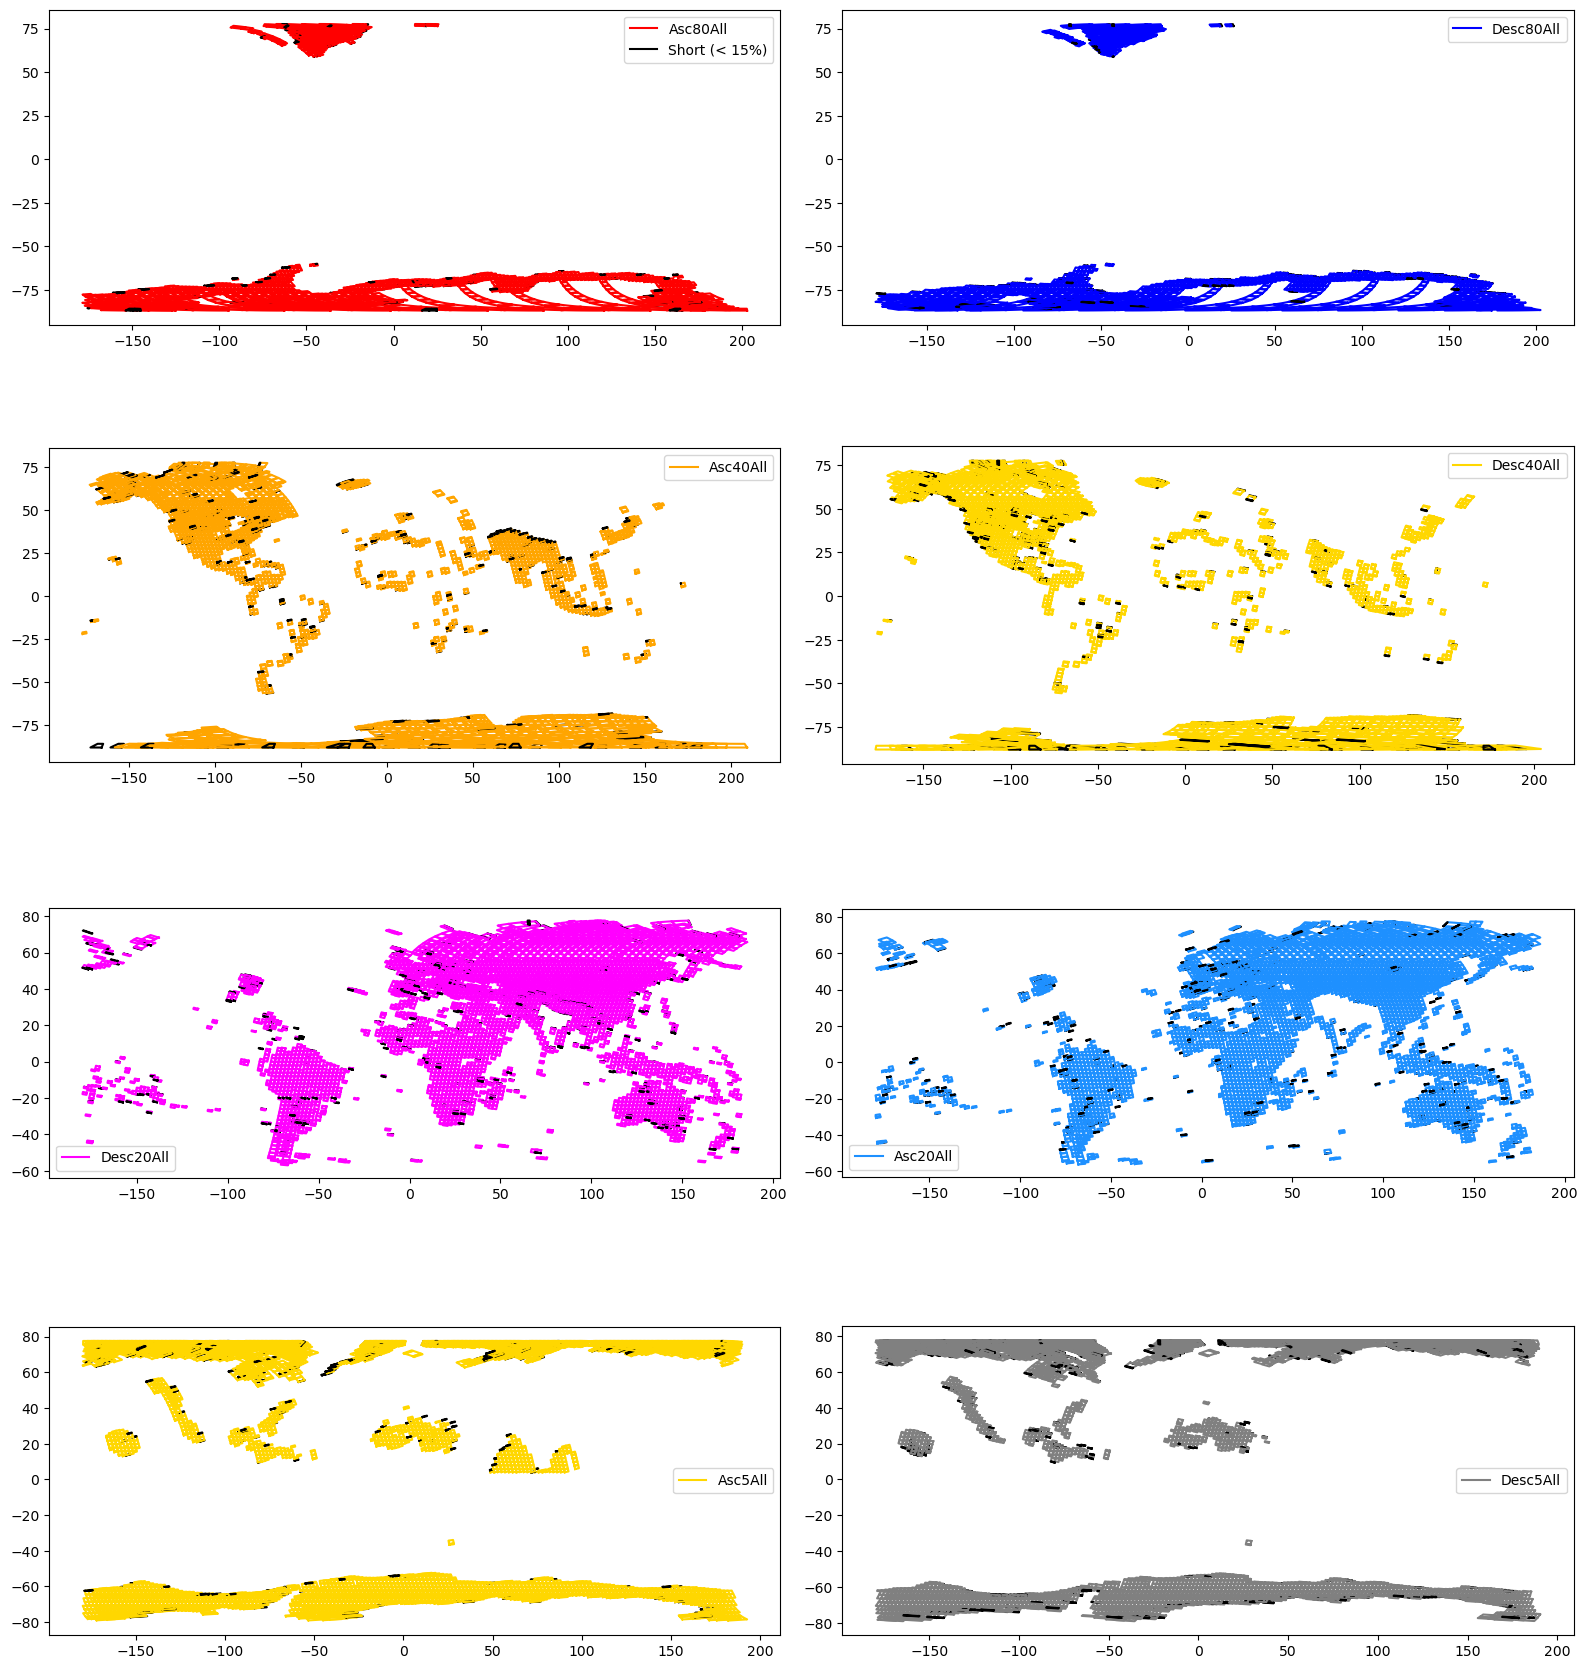

In [32]:
cycle = 1
dfs = readCycleKMLs(cycle, bwModes)
framed = insectPlanWithTFDB(cycle, dfs, plot=True)

Run the remaining cycles quietly.

In [ ]:
%%time
for cycle in range(2, 30):
    #continue
    dfs = readCycleKMLs(cycle, bwModes)
    _ = insectPlanWithTFDB(cycle, dfs, plot=False)